In [1]:
%pip install lightning

  Using cached lightning-2.6.1-py3-none-any.whl.metadata (44 kB)
Using cached lightning-2.6.1-py3-none-any.whl (853 kB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
!nvidia-smi

Wed Mar  4 15:49:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.181                Driver Version: 570.181        CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Quadro RTX 5000                On  |   00000000:01:00.0 Off |                  Off |
| 33%   30C    P8             16W /  230W |   14688MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# select gpu
%env CUDA_VISIBLE_DEVICES=6

env: CUDA_VISIBLE_DEVICES=6


In [4]:
import os
from pathlib import Path
import itertools 

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

from lightning.pytorch import LightningModule, Trainer, seed_everything
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import ModelCheckpoint

import torchvision.models as models
import torchmetrics

import pandas as pd
import matplotlib.pyplot as plt


random_state = 42
seed_everything(random_state,workers=True)

Seed set to 42


42

## Load Images using ImageFolder Dataset within the Datamodule

This is the adapted Datamodule. Changes: 
- renamed from GTSRBData to RoofData
- we don't have a csv describing the data anymore, but simply scan the folder (ImageFolder does this for us), so we can remove the csv_path as argument
- image_dir is the top dir of where the images are stored. We then only have to append "train", "val" etc.
- Instead of the TrafficSignDataset  we now use ImageFolder
- the transforms are just the bare minimum to get things running plus random flipping for augmentation (when using a pretrained model, we can also use the transforms provided with that model)

In [5]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset
import torch

class RoofData: # previously GTSRBData
    def __init__(self, image_dir, batch_size=128): #, image_size=28):
        self.image_dir = image_dir
        self.batch_size = batch_size
    

        train_tfm = transforms.Compose([
            #transforms.Resize((image_size, image_size)),
            #transforms.ToTensor(),
            models.EfficientNet_V2_S_Weights.IMAGENET1K_V1.transforms(),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5)
        ])
        eval_tfm = transforms.Compose([
            #transforms.Resize((image_size, image_size)),
            #transforms.ToTensor(),
            models.EfficientNet_V2_S_Weights.IMAGENET1K_V1.transforms()
        ])
        

        self.train_ds = datasets.ImageFolder( os.path.join(image_dir,"train"),  transform = train_tfm)
        self.val_ds   = datasets.ImageFolder(os.path.join(image_dir,"validation"), transform = eval_tfm)
        self.test_ds  = datasets.ImageFolder( os.path.join(image_dir,"test"),  transform = eval_tfm)

    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=self.batch_size, shuffle=True, num_workers=2)

    def val_dataloader(self):
        return DataLoader(self.val_ds, batch_size=64, shuffle=False, num_workers=2)

    def test_dataloader(self):
        return DataLoader(self.test_ds, batch_size=64, shuffle=False, num_workers=2)


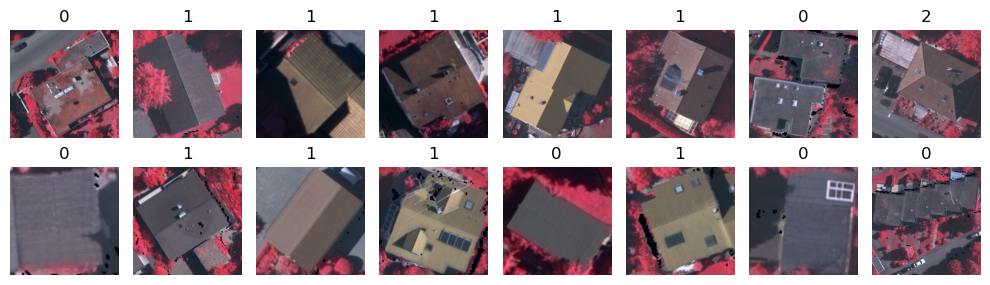

In [6]:
import matplotlib.pyplot as plt
import torch


image_dir = r"/home/jovyan/coursematerial/GIS/dataset_img_building_roofs/"
data = RoofData(image_dir=image_dir, batch_size=16)
train_dl = data.train_dataloader()

# get a batch
images, labels = next(iter(train_dl))

# plot
fig, axes = plt.subplots(2, 8, figsize=(10, 3))
for ax, img, lbl in zip(axes.flat, images, labels):
    img = (img - img.min()) / (img.max() - img.min())
    ax.imshow(img.transpose(0,2).transpose(0,1))
    ax.set_title(str(lbl.item()))
    ax.axis("off")
plt.tight_layout()
plt.show()

### 3 Model

All we have to do is to make sure the model is created with 3 outputs. Here, we also changed the model to an EfficientNet version. 
Note that the last layer of this version is called classifier and has two components. We only need to adapt the Linear layer.
````
(classifier): Sequential(
    (0): Dropout(p=0.2, inplace=True)
    (1): Linear(in_features=1280, out_features=1000, bias=True)
  )
````

In [7]:
import torchvision

# CNN Model from last week
class PretrainedModel(LightningModule):
    """CNN model for traffic sign classification using PyTorch Lightning"""
    
    def __init__(self, num_classes=43, lr=0.001):
        super().__init__()
        self.save_hyperparameters()
        self.lr = lr
        
        self.backbone = torchvision.models.efficientnet_v2_s(weights=torchvision.models.EfficientNet_V2_S_Weights.IMAGENET1K_V1)
        
        self.backbone.classifier[1] = torch.nn.Linear(in_features=1280, out_features=num_classes, bias=True)
        
        # Loss function
        self.loss_fn = nn.CrossEntropyLoss()
    
    def forward(self, x):
        x = self.backbone(x)        
        return x
    
    def _step(self, batch, stage):
        x, y = batch
        logits = self.forward(x)
        loss = self.loss_fn(logits, y)
        self.log(f"{stage}_loss", loss, on_step=False, on_epoch=True, prog_bar=(stage != 'test'))
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log(f"{stage}_acc", acc, on_step=False, on_epoch=True, prog_bar=(stage == "val"))
        return loss
        
    def training_step(self, batch, batch_idx):
        return self._step(batch,'train')
    
    def validation_step(self, batch, batch_idx):
        return self._step(batch, 'val')
    
    def test_step(self, batch, batch_idx):
        return self._step(batch,'test')

    def predict_step(self,batch,batch_idx):
        x, y = batch
        logits = self.forward(x)
        labels = logits.argmax(dim=1)
        return labels
    
    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)
        return optimizer

model = PretrainedModel(num_classes=3, lr=0.0001)

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /home/jovyan/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth
100%|██████████| 82.7M/82.7M [00:00<00:00, 115MB/s]


In [8]:
model

PretrainedModel(
  (backbone): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): FusedMBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
          )
          (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        )
        (1): FusedMBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (1): BatchNo

### Training
Adapt all the modules we are using to new names and make sure we set the number of classes to 3 everywhere.
Often, we use smaller learning rates for already pretrained models. 

In [9]:
seed_everything(42, workers=True)


data = RoofData(image_dir = image_dir, batch_size=32)
#model = PretrainedModel(num_classes=3, lr=0.0001) Already created in previous cell

logger = CSVLogger("logs", name="mnist_mlp")
ckpt = ModelCheckpoint(
    monitor="val_acc",
    mode="max",
    save_top_k=1,
    filename="mnist-mlp-{epoch:02d}-{val_acc:.4f}",
)

trainer = Trainer(
    max_epochs=10,
    accelerator="auto", # automatically choose which hardware to run on
    devices=1, # use 1 gpu only
    logger=logger,
    callbacks=[ckpt],
)

trainer.fit(model, train_dataloaders=data.train_dataloader(), val_dataloaders=data.val_dataloader())
best_path = ckpt.best_model_path
print("best checkpoint:", best_path)

best_model = PretrainedModel.load_from_checkpoint(best_path)
test_metrics = trainer.test(best_model, dataloaders=data.test_dataloader())
print("test metrics:", test_metrics)

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [6]

  | Name     | Type             | Params | Mode  | FLOPs
--------------------------------------------------------------
0 | backbone | EfficientNet     | 20.2 M | train | 0    
1 | loss_fn  | CrossEntropyLoss | 0      | train | 0    
--------------------------------------------------------------
20.2 M    Trainable params
0         Non-trainable params
20.2 M    Total params
80.725    Total estimated model params size (MB)
715       Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/opt/conda/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:317: The number of training batches (10) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

`Trainer.fit` stopped: `max_epochs=10` reached.


best checkpoint: logs/mnist_mlp/version_2/checkpoints/mnist-mlp-epoch=08-val_acc=0.9861.ckpt


/opt/conda/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [6]


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.9756097793579102
        test_loss           0.0942789688706398
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
test metrics: [{'test_loss': 0.0942789688706398, 'test_acc': 0.9756097793579102}]


### curves and confusion matrix

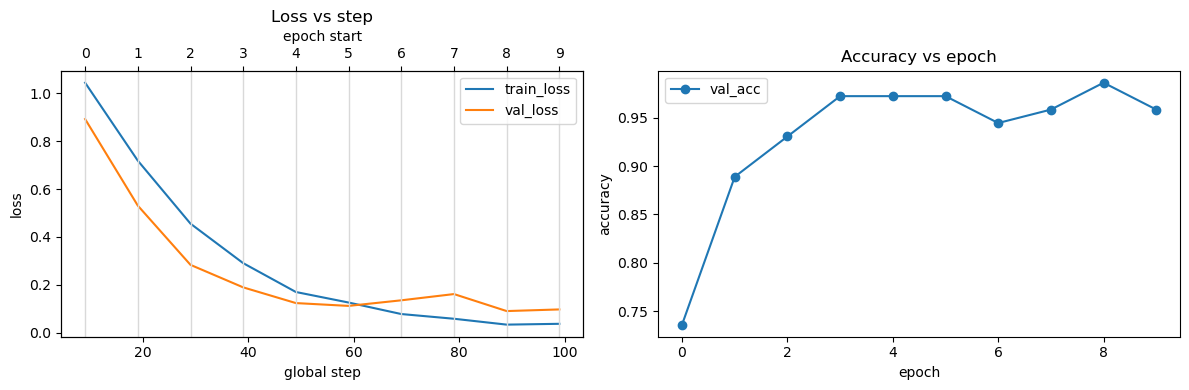

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_metrics_step_and_epoch(metrics_csv):
    df = pd.read_csv(metrics_csv)

    # training loss per step
    df_train = df.dropna(subset=["train_loss"])[["step", "epoch", "train_loss"]]

    # validation loss has valid step values too; keep one row per step
    df_val_loss = (
        df.dropna(subset=["val_loss"])[["step", "epoch", "val_loss"]]
        .groupby("step", as_index=False).last()
    )

    # epoch-level metrics (last logged per epoch)
    df_epoch = (
        df.dropna(subset=["epoch"])
          .groupby("epoch", as_index=False).last()
    )
    acc_cols = [c for c in ["acc", "val_acc"] if c in df_epoch.columns]

    # step positions where each epoch starts
    epoch_starts = (
        df_train.groupby("epoch", as_index=False)["step"].min()
        .sort_values("epoch")
    )

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # left: losses vs global step
    ax1.plot(df_train["step"], df_train["train_loss"], label="train_loss")
    if not df_val_loss.empty:
        ax1.plot(df_val_loss["step"], df_val_loss["val_loss"], label="val_loss")
    for _, r in epoch_starts.iterrows():
        ax1.axvline(r["step"], color="0.85", linewidth=1)

    ax1.set_xlabel("global step")
    ax1.set_ylabel("loss")
    ax1.set_title("Loss vs step")
    ax1.legend()

    # top x-axis: epoch ticks at their start steps
    ax1_top = ax1.twiny()
    ax1_top.set_xlim(ax1.get_xlim())
    ax1_top.set_xticks(epoch_starts["step"].to_list())
    ax1_top.set_xticklabels(epoch_starts["epoch"].astype(int).to_list())
    ax1_top.set_xlabel("epoch start")

    # right: accuracy vs epoch
    for c in acc_cols:
        ax2.plot(df_epoch["epoch"], df_epoch[c], label=c, marker="o")
    ax2.set_xlabel("epoch")
    ax2.set_ylabel("accuracy")
    ax2.set_title("Accuracy vs epoch")
    if acc_cols:
        ax2.legend()

    plt.tight_layout()
    plt.show()


plot_metrics_step_and_epoch(os.path.join(logger.log_dir, "metrics.csv"))

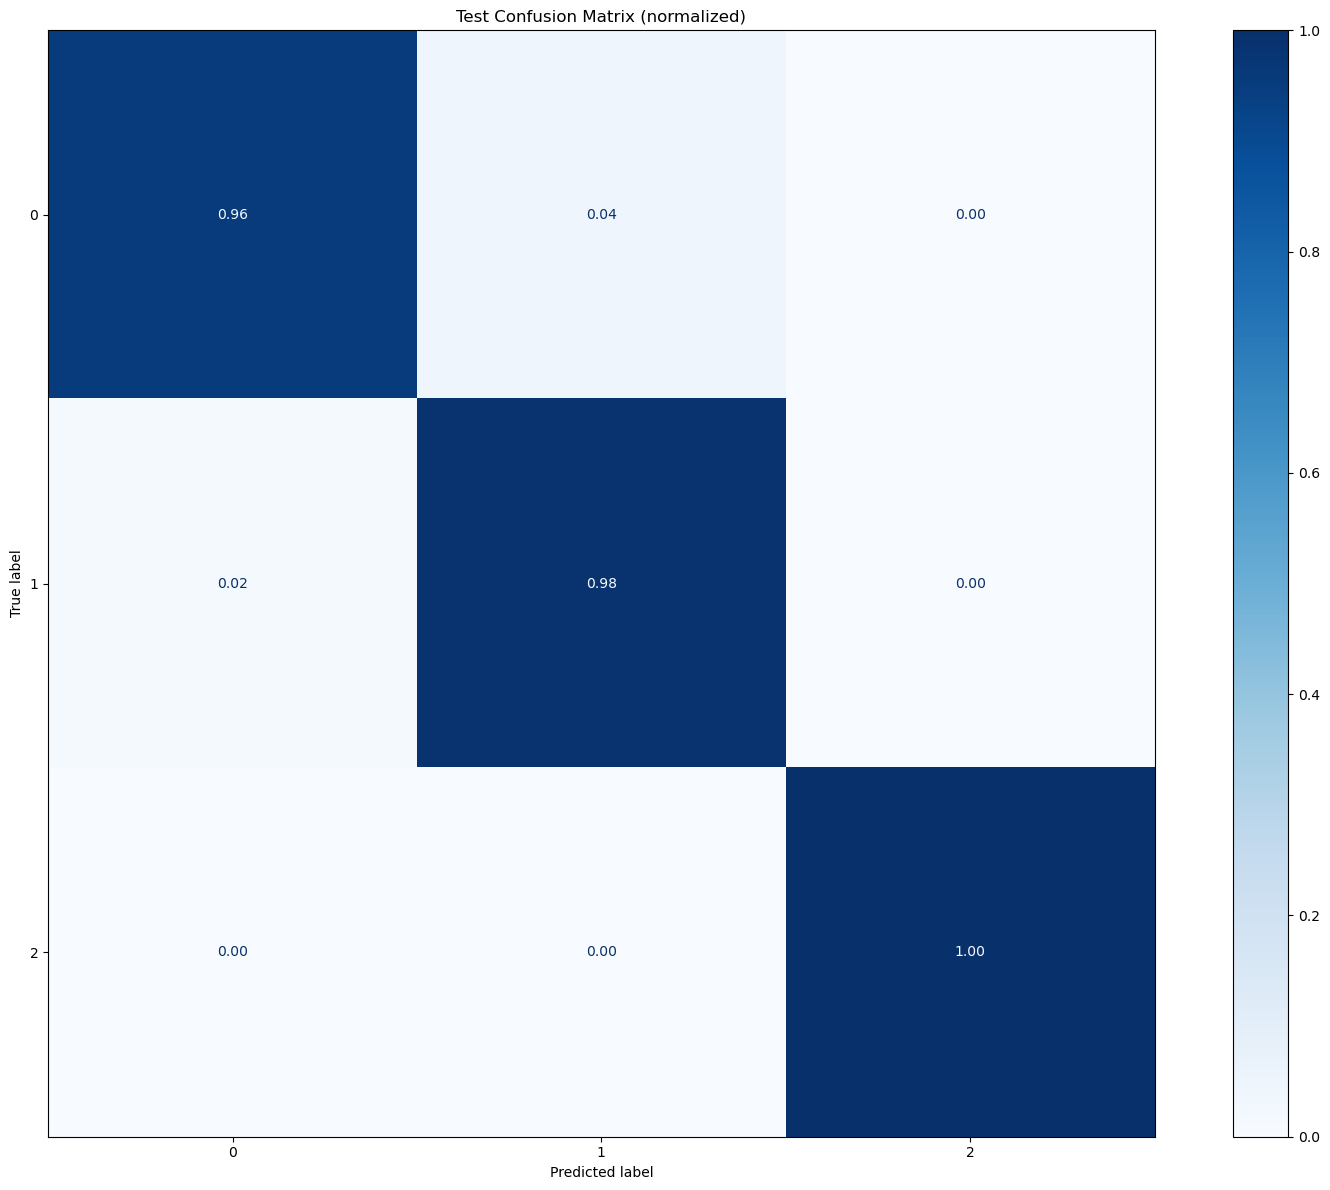

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import torch, os
from pathlib import Path
import numpy as np

def plot_confmat(model, dataloader, num_classes, class_names=None, device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device).eval()

    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            logits = model(x)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            y_pred.append(preds)
            y_true.append(y.numpy())
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)), normalize="true")
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names or list(range(num_classes)))
    fig, ax = plt.subplots(figsize=(16, 12))
    disp.plot(ax=ax, values_format=".2f", cmap="Blues", colorbar=True)
    ax.set_title("Test Confusion Matrix (normalized)")
    plt.tight_layout()
    plt.show()

num_classes = 3  
plot_confmat(best_model, data.test_dataloader(), num_classes=num_classes)
